# 4GCN vs 7GCN — worked examples

Two qualitative examples on the SemEval-2016 restaurant test set, using the saved
backup-model predictions in `eval_files/`:

In [1]:
import re
from collections import Counter

import torch
import torch.nn.functional as F
import xml.etree.ElementTree as ET
import pandas as pd

YEAR = "2016"
LBL = {0: "negative", 1: "neutral", 2: "positive"}
POL = {"negative": 0, "neutral": 1, "positive": 2}


def load_eval(path):
    """Rows of (gold, pred, sentence, aspect). NOTE column order: gold first, pred second."""
    rows = []
    for line in open(path):
        parts = line.rstrip("\n").split("\t")
        if len(parts) >= 4:
            rows.append((int(parts[0]), int(parts[1]), parts[2], parts[3]))
    return rows


rows4 = load_eval(f"eval_files/4gcn_{YEAR}.txt")
rows7 = load_eval(f"eval_files/7gcn_{YEAR}.txt")
acc4 = sum(g == p for g, p, _, _ in rows4) / len(rows4)
acc7 = sum(g == p for g, p, _, _ in rows7) / len(rows7)
print(f"instances: 4GCN={len(rows4)}  7GCN={len(rows7)}")
print(f"backup-only accuracy: 4GCN={acc4:.4f}  7GCN={acc7:.4f}")

instances: 4GCN=650  7GCN=650
backup-only accuracy: 4GCN=0.8908  7GCN=0.8985


In [2]:
def lookup(rows, sub, aspect):
    """(gold, pred, sentence) for the unique row whose sentence contains `sub` and aspect==`aspect`."""
    hits = [(g, p, s) for g, p, s, a in rows if sub.lower() in s.lower() and a == aspect]
    assert len(hits) == 1, f"expected exactly 1 match, got {len(hits)} for {sub!r}/{aspect!r}"
    return hits[0]


def show(rows4, rows7, sub, aspect):
    g, p4, sent = lookup(rows4, sub, aspect)
    _, p7, _ = lookup(rows7, sub, aspect)
    print(f"sentence : {sent}")
    print(f"aspect   : {aspect}")
    print(f"gold     : {LBL[g]}")
    print(f"4GCN     : {LBL[p4]:8}  ({'correct' if p4 == g else 'WRONG'})")
    print(f"7GCN     : {LBL[p7]:8}  ({'correct' if p7 == g else 'WRONG'})")
    return g, p4, p7

Example 1 — both models correct

In [3]:
_ = show(rows4, rows7, sub="staff was very nice and courteous", aspect="staff")

sentence : the staff was very nice and courteous and obviously chinese .
aspect   : staff
gold     : positive
4GCN     : positive  (correct)
7GCN     : positive  (correct)


## Example 2 — 7GCN correct, 4GCN wrong

In [4]:
gold2, p4_2, p7_2 = show(rows4, rows7, sub="great pizza , poor service", aspect="pizza")

sentence : great pizza , poor service
aspect   : pizza
gold     : positive
4GCN     : negative  (WRONG)
7GCN     : positive  (correct)


In [5]:
def parse_xml(path):
    """(sentence, target, category, polarity) per non-NULL opinion, in document order.
    This order matches cross_features instance_idx (1-to-1)."""
    out = []
    for sent in ET.parse(path).getroot().iter("sentence"):
        text = sent.findtext("text")
        ops = sent.find("Opinions")
        if ops is None:
            continue
        for op in ops.findall("Opinion"):
            if op.attrib.get("target", "NULL") == "NULL":
                continue
            out.append((text.strip(), op.attrib["target"], op.attrib["category"], op.attrib["polarity"]))
    return out


train = parse_xml(f"../data/train{YEAR}restaurant.xml")
test = parse_xml(f"../data/test{YEAR}restaurant.xml")

payload = torch.load(f"../data/cross_features_{YEAR}.pt", map_location="cpu", weights_only=False)
Xtr = F.normalize(payload["train"]["X"], dim=1)  # frozen pretrained-BERT node features x_m
Xte = F.normalize(payload["test"]["X"], dim=1)
assert len(train) == Xtr.shape[0] and len(test) == Xte.shape[0]
print(f"train mentions: {len(train)}  test mentions: {len(test)}  feat-dim: {Xtr.shape[1]}")
print(f"node features : {payload['bert_model']}  /  {payload['pooling']}")

train mentions: 1880  test mentions: 650  feat-dim: 1024
node features : bert-large-uncased  /  aspect_subword_mean_on_cls_sent_sep_aspect_sep


In [6]:
def norm(s):
    return re.sub(r"[^a-z0-9]", "", s.lower())


# Locate Example 2 in the cross-features test set (tokenisation differs from the eval files,
# so match on normalised sentence + aspect + gold polarity).
key = (norm("great pizza , poor service"), norm("pizza"), gold2)
cand = [i for i, (t, tgt, cat, pol) in enumerate(test)
        if (norm(t), norm(tgt), POL[pol]) == key]
assert len(cand) == 1, f"expected 1 cross-features match, got {len(cand)}"
ti = cand[0]
print("centre mention:", test[ti])

centre mention: ('Great Pizza, Poor Service', 'Pizza', 'FOOD#QUALITY', 'positive')


In [7]:
# --- XSimGCN neighbourhood: top-K cosine-similar TRAIN mentions ---
K = 20  # opt.xsim_top_k default
sims = (Xte[ti:ti + 1] @ Xtr.T).squeeze(0)
topk = torch.topk(sims, K).indices.tolist()

xsim_mix = Counter(train[j][3] for j in topk)
print("XSim top-20 neighbour sentiment mix:", dict(xsim_mix))

xsim_df = pd.DataFrame([
    {"cos_sim": round(sims[j].item(), 3), "sentiment": train[j][3],
     "category": train[j][2], "aspect": train[j][1], "sentence": train[j][0][:65]}
    for j in topk
])
xsim_df.head(10)

XSim top-20 neighbour sentiment mix: {'positive': 16, 'negative': 4}


,cos_sim,sentiment,category,aspect,sentence
0,0.961,positive,FOOD#QUALITY,pizza,Great pizza and fantastic service.
1,0.930,negative,FOOD#PRICES,pizza,But the pizza is way to expensive.
2,0.927,negative,FOOD#QUALITY,pizza,I think the pizza is so overrated and was unde...
3,0.923,positive,FOOD#QUALITY,pizza,The pizza is delicious and the proprietor is o...
4,0.921,positive,FOOD#QUALITY,pizza,"By far, the best pizza in Manhattan."
5,0.920,positive,FOOD#QUALITY,pizza,Hands down the best pizza on the planet.
6,0.918,positive,FOOD#QUALITY,pizza,Great pizza for lunch place.
7,0.916,positive,FOOD#QUALITY,pizza,Who has room for Cheesesticks with the best pi...
8,0.916,positive,FOOD#QUALITY,pizza,Right off the L in Brooklyn this is a nice coz...
9,0.915,positive,FOOD#QUALITY,Pizza,Awsome Pizza especially the Margheritta slice.


In [8]:
# --- XCatGCN neighbourhood: all TRAIN mentions sharing the centre's category ---
cat = test[ti][2]
pool = [j for j, r in enumerate(train) if r[2] == cat]
xcat_mix = Counter(train[j][3] for j in pool)
print(f"XCat pool: {len(pool)} train mentions sharing category {cat!r}")
print("sentiment mix:", dict(xcat_mix))
print("as %:", {k: round(100 * v / len(pool), 1) for k, v in xcat_mix.items()})

XCat pool: 765 train mentions sharing category 'FOOD#QUALITY'
sentiment mix: {'negative': 172, 'positive': 566, 'neutral': 27}
as %: {'negative': 22.5, 'positive': 74.0, 'neutral': 3.5}


Figure generation

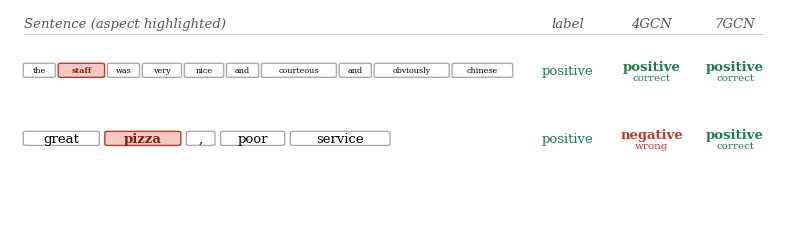

saved /Users/sebastiaanhelbing/Desktop/thesis/HAABSA7GCN/src/figures/fig_examples_simple.png


In [ ]:
import os
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ---- pull labels straight from the eval lookups (no hand-typed labels) ------
def _labels(sub, aspect):
    g, p4, _ = lookup(rows4, sub, aspect)
    _, p7, _ = lookup(rows7, sub, aspect)
    return LBL[g], LBL[p4], LBL[p7]

g1, p4_1, p7_1 = _labels("staff was very nice and courteous", "staff")
g2, p4_2_, p7_2_ = _labels("great pizza , poor service", "pizza")

EXAMPLES = [
    {
        "tokens": ["the", "staff", "was", "very", "nice", "and",
                   "courteous", "and", "obviously", "chinese"],
        "aspect_idx": [1],
        "gold": g1, "p4": p4_1, "p7": p7_1,
    },
    {
        "tokens": ["great", "pizza", ",", "poor", "service"],
        "aspect_idx": [1],
        "gold": g2, "p4": p4_2_, "p7": p7_2_,
    },
]
# -----------------------------------------------------------------------------

POS = "#1e7d4f"
NEG = "#c0392b"
ASP = "#f6c9c0"
GREY = "#555555"

plt.rcParams.update({"font.family": "serif", "font.size": 11,
                     "svg.fonttype": "none"})

fig, ax = plt.subplots(figsize=(8.0, 2.6))
ax.set_xlim(0, 110)
ax.set_ylim(0, 100)
ax.axis("off")

# column headers
ax.text(2, 92, "Sentence (aspect highlighted)", fontsize=9.5,
        style="italic", color=GREY)
ax.text(80, 92, "label", fontsize=9.5, style="italic", color=GREY, ha="center")
ax.text(92, 92, "4GCN", fontsize=9.5, style="italic", color=GREY, ha="center")
ax.text(104, 92, "7GCN", fontsize=9.5, style="italic", color=GREY, ha="center")
ax.plot([2, 108], [89, 89], color="#cccccc", lw=0.8)

def colour(label):
    return POS if label == "positive" else (NEG if label == "negative" else GREY)

def pred_cell(x, y, label, correct):
    col = colour(label)
    ax.text(x, y + 1.6, label, ha="center", va="center", color=col,
            fontsize=9.5, fontweight="bold")
    ax.text(x, y - 3.0, "correct" if correct else "wrong", ha="center",
            va="center", color=col, fontsize=7.5)

row_y = [70, 40]
STRIP_X0 = 2.0
STRIP_X1 = 72.0          # token strip must end before the 'label' column
for ex, y in zip(EXAMPLES, row_y):
    toks = ex["tokens"]
    gap = 1.0
    # width each token would take at base sizing, then scale to fit
    base = [2.2 + 1.7 * len(t) for t in toks]
    total = sum(base) + gap * (len(toks) - 1)
    scale = min(1.0, (STRIP_X1 - STRIP_X0) / total)
    fs = 9.5 * scale
    x = STRIP_X0
    for i, tok in enumerate(toks):
        w = base[i] * scale
        if i in ex["aspect_idx"]:
            fc, ec, tc, fw = ASP, NEG, "#7a1f12", "bold"
        else:
            fc, ec, tc, fw = "white", "#aaaaaa", "black", "normal"
        ax.add_patch(FancyBboxPatch((x, y), w, 6.0,
                     boxstyle="round,pad=0.10,rounding_size=0.5",
                     linewidth=1.0, edgecolor=ec, facecolor=fc))
        ax.text(x + w / 2, y + 3.0, tok, ha="center", va="center",
                color=tc, fontweight=fw, fontsize=fs)
        x += w + gap * scale

    cy = y + 3.0
    ax.text(80, cy, ex["gold"], ha="center", va="center",
            color=colour(ex["gold"]), fontsize=9.5)
    pred_cell(92, cy, ex["p4"], ex["p4"] == ex["gold"])
    pred_cell(104, cy, ex["p7"], ex["p7"] == ex["gold"])

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
out_png = "figures/fig_examples_simple.png"
fig.savefig(out_png, dpi=200, bbox_inches="tight")
plt.show()
print("saved", os.path.abspath(out_png))